In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

# 1. Load data
df= pd.read_excel('https://github.com/Apur52027/Dataset_ML/blob/main/BSMDD_v3_textcleaned%20-%2021K.xlsx?raw=true')

texts = df['text'].astype(str).values
labels = df['label'].values

# 2. Bengali text cleaning
def clean_bengali_text(text):
    # Remove URLs, mentions, extra spaces
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)
    # Remove punctuation except Bengali punctuations (।, etc.)
    text = re.sub(r'[^\u0980-\u09FF\s।]', '', text)  # keep Bengali Unicode range + space + '।'
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

texts_clean = [clean_bengali_text(t) for t in texts]

# 3. Split data (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    texts_clean, labels, test_size=0.2, random_state=42, stratify=labels
)

# 4. Check class distribution
print(f"Train: {np.bincount(y_train)} | Val: {np.bincount(y_test)}")

Train: [8759 8769] | Val: [2190 2192]


In [ ]:
# 5. Load tokenizer and model
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

# Approach 1: Fine‑tune BanglaBERT

In [ ]:
from transformers import EarlyStoppingCallback

In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

# 1. Load data
df= pd.read_excel('https://github.com/Apur52027/Dataset_ML/blob/main/BSMDD_v3_textcleaned%20-%2021K.xlsx?raw=true')

texts = df['text'].astype(str).values
labels = df['label'].values

# 2. Bengali text cleaning
def clean_bengali_text(text):
    # Remove URLs, mentions, extra spaces
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)
    # Remove punctuation except Bengali punctuations (।, etc.)
    text = re.sub(r'[^\u0980-\u09FF\s।]', '', text)  # keep Bengali Unicode range + space + '।'
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

texts_clean = [clean_bengali_text(t) for t in texts]

# 3. Split data (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    texts_clean, labels, test_size=0.2, random_state=42, stratify=labels
)

# 4. Check class distribution
print(f"Train: {np.bincount(y_train)} | Val: {np.bincount(y_test)}")

# 5. Load tokenizer and model
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 6. Tokenize dataset
def tokenize_function(examples):
    return tokenizer(examples, padding="max_length", truncation=True, max_length=256)

train_encodings = tokenize_function(X_train)
val_encodings = tokenize_function(X_test)

# 7. Create PyTorch Dataset
class BengaliDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = BengaliDataset(train_encodings, y_train)
val_dataset = BengaliDataset(val_encodings, y_test)

# 8. Define metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

# 9. Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True
)

# 10. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 11. Train
trainer.train()

# 12. Evaluate
eval_results = trainer.evaluate()
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")

Train: [8759 8769] | Val: [2190 2192]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.265103,0.283038,0.906892,0.905556
2,0.202376,0.260812,0.914423,0.916685
3,0.140427,0.256051,0.919900,0.920714
4,0.079174,0.307759,0.928571,0.928685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Validation Accuracy: 0.9286


In [ ]:
print(f"Testing Accuracy (Validation Accuracy): {eval_results['eval_accuracy']:.4f}")
print("Training accuracy is not directly logged by the Hugging Face Trainer per epoch by default and thus is not available in the log history.")

Testing Accuracy (Validation Accuracy): 0.9286
Training accuracy is not directly logged by the Hugging Face Trainer per epoch by default and thus is not available in the log history.


In [ ]:
from sklearn.metrics import classification_report

# Get predictions on the validation set
predictions = trainer.predict(val_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Generate and print the classification report
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2190
           1       0.93      0.93      0.93      2192

    accuracy                           0.93      4382
   macro avg       0.93      0.93      0.93      4382
weighted avg       0.93      0.93      0.93      4382



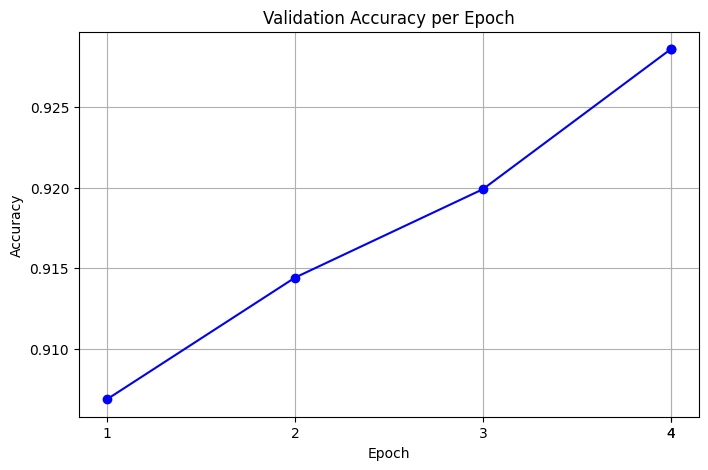

In [ ]:
import matplotlib.pyplot as plt

# Extract evaluation accuracies and epochs from trainer.state.log_history
epochs = []
accuracies = []
for log_entry in trainer.state.log_history:
    if 'eval_accuracy' in log_entry:
        epochs.append(log_entry['epoch'])
        accuracies.append(log_entry['eval_accuracy'])

# Plotting the accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracies, marker='o', linestyle='-', color='b')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(epochs) # Ensure x-axis ticks are at epoch values
plt.show()

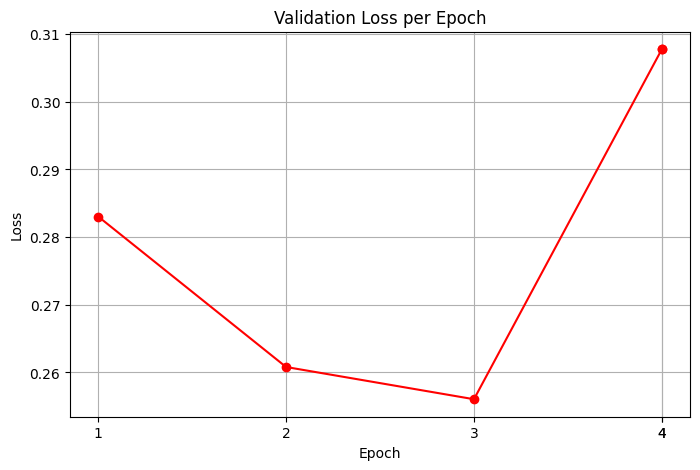

In [ ]:
import matplotlib.pyplot as plt

# Extract evaluation losses and epochs from trainer.state.log_history
epochs_loss = []
losses = []
for log_entry in trainer.state.log_history:
    if 'eval_loss' in log_entry:
        epochs_loss.append(log_entry['epoch'])
        losses.append(log_entry['eval_loss'])

# Plotting the loss graph
plt.figure(figsize=(8, 5))
plt.plot(epochs_loss, losses, marker='o', linestyle='-', color='r')
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(epochs_loss) # Ensure x-axis ticks are at epoch values
plt.show()

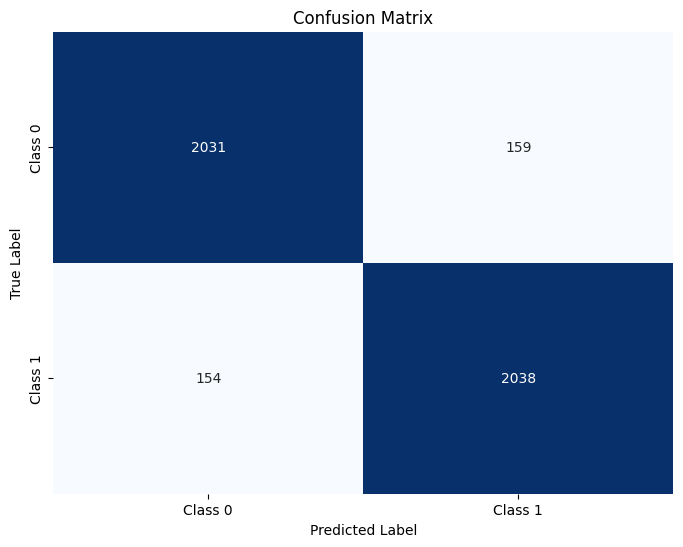

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

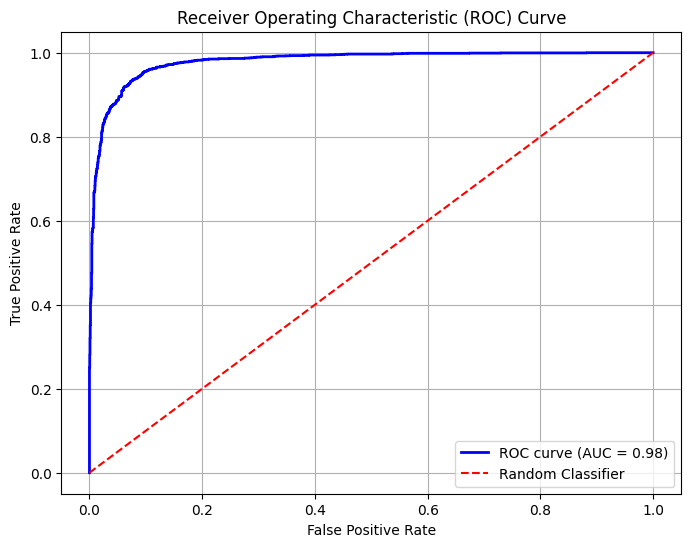

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities for the positive class
# predictions.predictions contains logits, so apply softmax or equivalent for probabilities
probabilities = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1].numpy()

# Calculate ROC curve
# y_true are the actual labels, y_score are the prediction probabilities of the positive class
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

# Calculate AUC score
auc_score = roc_auc_score(y_test, probabilities)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()